# Question 1 — Intensity Transformations on the Runway Image
- (a) Gamma correction γ = 0.5
- (b) Gamma correction γ = 2
- (c) Contrast stretching r₁=0.2, r₂=0.8

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def show(img, title='', cmap='gray', vmin=0, vmax=1):
    plt.figure(figsize=(6, 5))
    plt.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.axis('off')
    plt.show()

def show_all(images, titles, cmap='gray', cols=4, vmin=0, vmax=1, save=None):
    fig, axes = plt.subplots(1, len(images), figsize=(5 * len(images), 5))
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    if save: plt.savefig(save, dpi=150, bbox_inches='tight')
    plt.show()

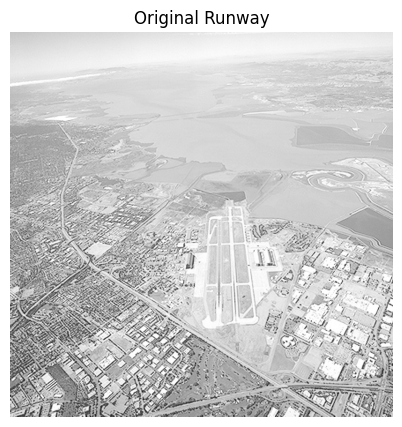

In [2]:
# Load and normalize to [0,1] for direct power operations
runway = cv.imread('images/runway.png', cv.IMREAD_GRAYSCALE)
assert runway is not None
f = runway / 255.0
show(f, 'Original Runway')

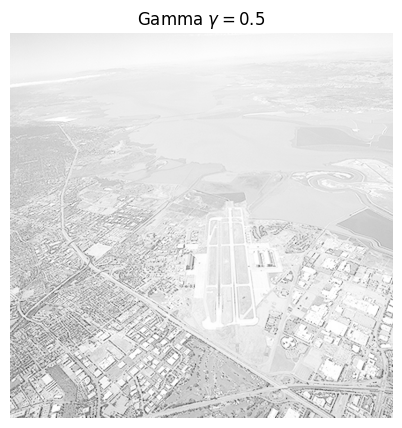

In [3]:
# (a) Gamma γ=0.5 — curve bows upward, brightens dark pixels
g_05 = np.power(f, 0.5)
show(g_05, r'Gamma $\gamma=0.5$')

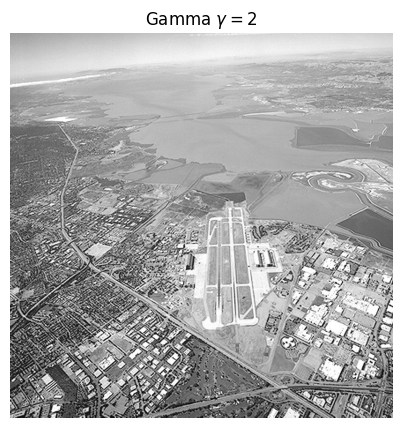

In [4]:
# (b) Gamma γ=2 — curve bows downward, darkens bright pixels
g_2 = np.power(f, 2.0)
show(g_2, r'Gamma $\gamma=2$')

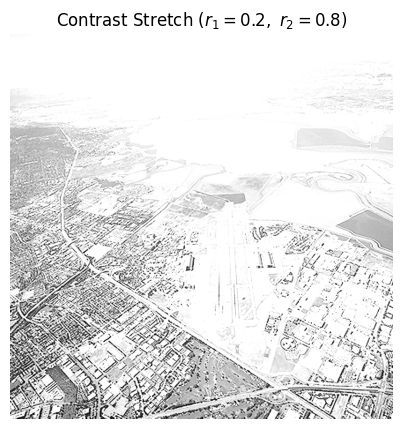

In [5]:
# (c) Contrast stretching — piecewise linear transform
def contrast_stretch(img, r1=0.2, r2=0.8):
    out = np.zeros_like(img)
    out[img < r1] = 0
    mask = (img >= r1) & (img <= r2)
    out[mask] = (img[mask] - r1) / (r2 - r1)
    out[img > r2] = 1
    return out

g_cs = contrast_stretch(f)
show(g_cs, r'Contrast Stretch ($r_1=0.2,\ r_2=0.8$)')

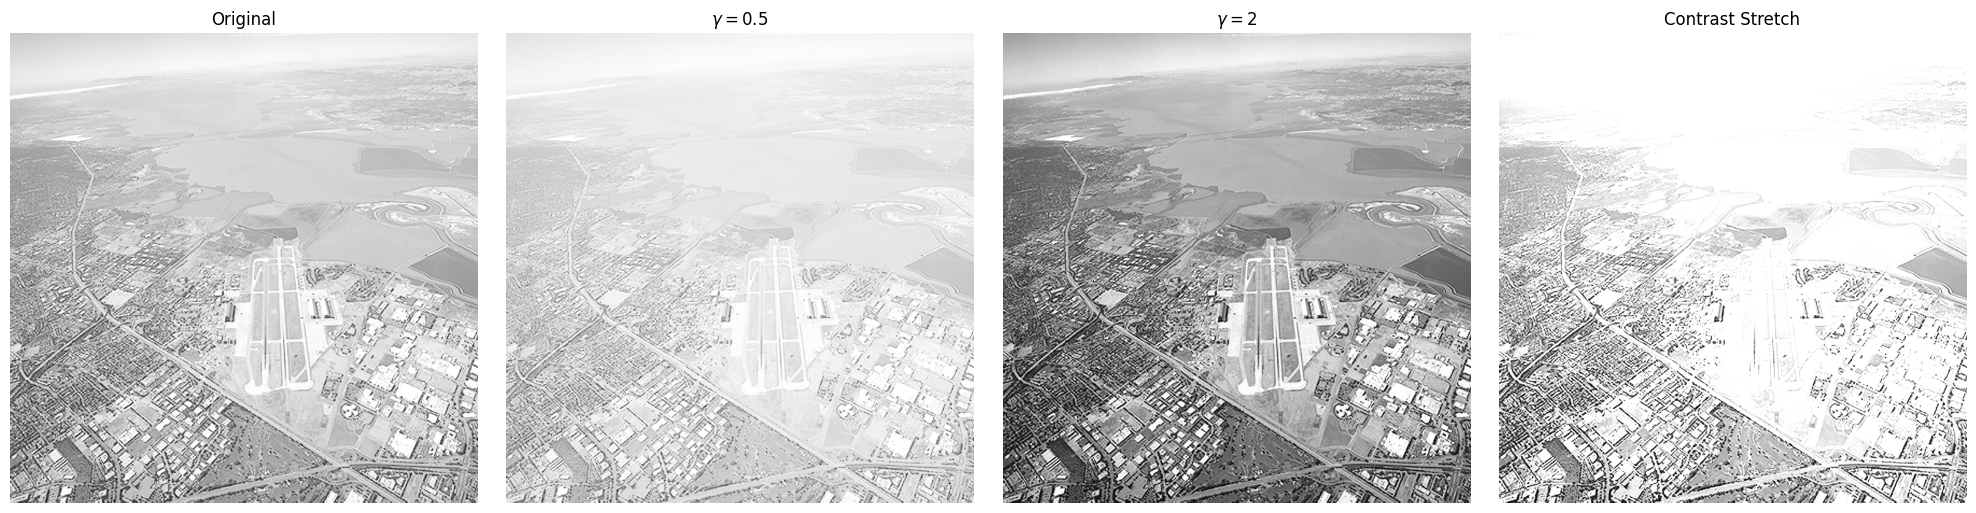

In [6]:
# Summary
show_all(
    [f, g_05, g_2, g_cs],
    ['Original', r'$\gamma=0.5$', r'$\gamma=2$', 'Contrast Stretch'],
    save='outputs/q1_summary.png'
)